In [ ]:
## Importing librries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Bidirectional
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import (LSTM, Dense, Bidirectional,Input ,Add)
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/surface-air-temperature-monthly-mean.csv",index_col = "month",parse_dates = ["month"])
df.index_freq = "MS"

In [ ]:
df.head()

,mean_temp
month,
1982-01-01,25.9
1982-02-01,27.1
1982-03-01,27.2
1982-04-01,27.0
1982-05-01,28.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 462 entries, 1982-01-01 to 2020-06-01
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   mean_temp  462 non-null    float64
dtypes: float64(1)
memory usage: 7.2 KB


In [ ]:
df.tail

<bound method NDFrame.tail of             mean_temp
month                
1982-01-01       25.9
1982-02-01       27.1
1982-03-01       27.2
1982-04-01       27.0
1982-05-01       28.0
...               ...
2020-02-01       27.9
2020-03-01       28.6
2020-04-01       28.9
2020-05-01       28.9
2020-06-01       28.1

[462 rows x 1 columns]>

In [ ]:
df.isnull().sum()

,0
mean_temp,0


<Axes: xlabel='month'>

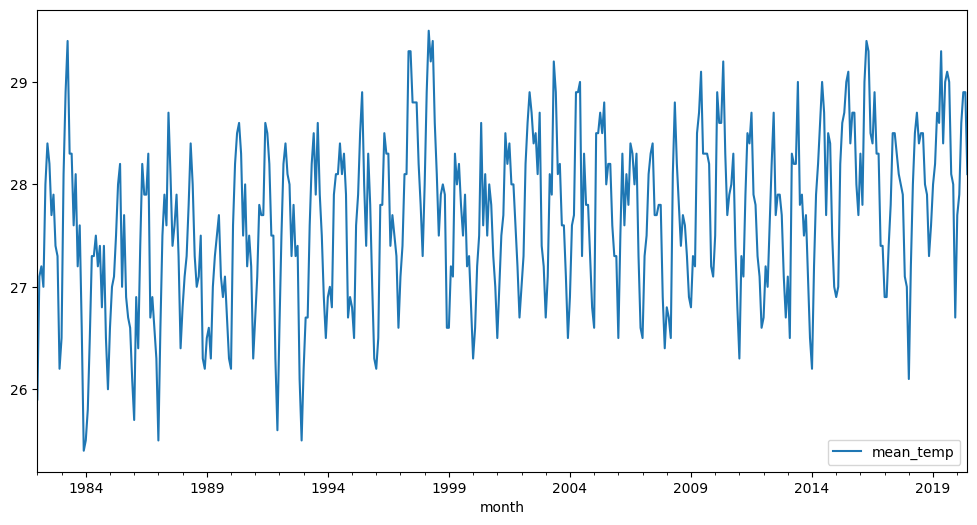

In [ ]:
df.plot(figsize=(12,6))

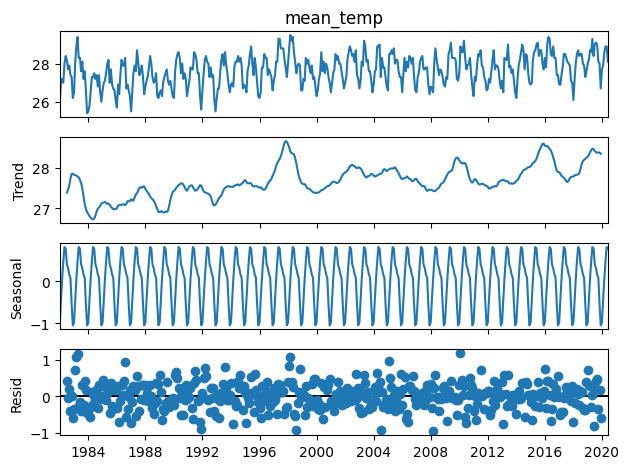

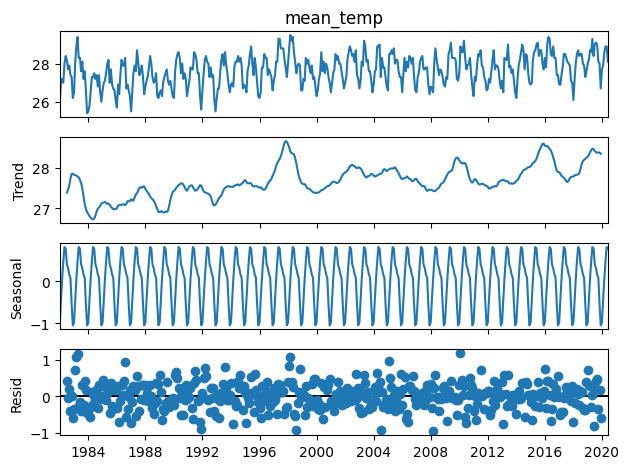

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
results = seasonal_decompose(df["mean_temp"])
results.plot()

In [ ]:
df.shape

(462, 1)

In [ ]:
len(df)

462

In [ ]:
#Preprocess the data

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)
scaled_data

array([[0.12195122],
       [0.41463415],
       [0.43902439],
       [0.3902439 ],
       [0.63414634],
       [0.73170732],
       [0.68292683],
       [0.56097561],
       [0.6097561 ],
       [0.48780488],
       [0.46341463],
       [0.19512195],
       [0.26829268],
       [0.65853659],
       [0.85365854],
       [0.97560976],
       [0.70731707],
       [0.70731707],
       [0.53658537],
       [0.65853659],
       [0.43902439],
       [0.53658537],
       [0.29268293],
       [0.        ],
       [0.02439024],
       [0.09756098],
       [0.26829268],
       [0.46341463],
       [0.46341463],
       [0.51219512],
       [0.43902439],
       [0.48780488],
       [0.34146341],
       [0.48780488],
       [0.26829268],
       [0.14634146],
       [0.29268293],
       [0.3902439 ],
       [0.41463415],
       [0.51219512],
       [0.63414634],
       [0.68292683],
       [0.3902439 ],
       [0.56097561],
       [0.36585366],
       [0.31707317],
       [0.29268293],
       [0.170

In [ ]:

# Create dataset sequences
import numpy as np
def create_sequences(data, window=30):
  X,y = [],[]
  for i in range(window,len(data)):
    X.append(data[i-window:i])
    y.append(data[i])
    return np.array(X),np.array(y)
    window_size = 30
    X , y = create_sequences(data,window_size)


In [ ]:
import numpy as np
# Create dataset sequences

def create_sequences(data, window=30):
  X,y = [],[]
  for i in range(window,len(data)):
    X.append(data[i-window:i])
    y.append(data[i])
  return np.array(X),np.array(y)

window_size = 30
X , y = create_sequences(scaled_data,window_size)
print(X.shape)


(432, 30, 1)


In [ ]:
X.shape

(432, 30, 1)

In [ ]:
y.shape

(432, 1)

In [ ]:
#train_test_split
split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
X_train.shape

(345, 30, 1)

In [ ]:
X_test.shape

(87, 30, 1)

In [ ]:
y_train.shape

(345, 1)

In [ ]:
y_test.shape

(87, 1)

In [ ]:
X[0]

array([[0.12195122],
       [0.41463415],
       [0.43902439],
       [0.3902439 ],
       [0.63414634],
       [0.73170732],
       [0.68292683],
       [0.56097561],
       [0.6097561 ],
       [0.48780488],
       [0.46341463],
       [0.19512195],
       [0.26829268],
       [0.65853659],
       [0.85365854],
       [0.97560976],
       [0.70731707],
       [0.70731707],
       [0.53658537],
       [0.65853659],
       [0.43902439],
       [0.53658537],
       [0.29268293],
       [0.        ],
       [0.02439024],
       [0.09756098],
       [0.26829268],
       [0.46341463],
       [0.46341463],
       [0.51219512]])

In [ ]:
y[0]

array([0.43902439])

In [ ]:
X[30]

array([[0.43902439],
       [0.48780488],
       [0.34146341],
       [0.48780488],
       [0.26829268],
       [0.14634146],
       [0.29268293],
       [0.3902439 ],
       [0.41463415],
       [0.51219512],
       [0.63414634],
       [0.68292683],
       [0.3902439 ],
       [0.56097561],
       [0.36585366],
       [0.31707317],
       [0.29268293],
       [0.17073171],
       [0.07317073],
       [0.36585366],
       [0.24390244],
       [0.48780488],
       [0.68292683],
       [0.6097561 ],
       [0.6097561 ],
       [0.70731707],
       [0.31707317],
       [0.36585366],
       [0.29268293],
       [0.2195122 ]])

In [ ]:
X[1]

array([[0.41463415],
       [0.43902439],
       [0.3902439 ],
       [0.63414634],
       [0.73170732],
       [0.68292683],
       [0.56097561],
       [0.6097561 ],
       [0.48780488],
       [0.46341463],
       [0.19512195],
       [0.26829268],
       [0.65853659],
       [0.85365854],
       [0.97560976],
       [0.70731707],
       [0.70731707],
       [0.53658537],
       [0.65853659],
       [0.43902439],
       [0.53658537],
       [0.29268293],
       [0.        ],
       [0.02439024],
       [0.09756098],
       [0.26829268],
       [0.46341463],
       [0.46341463],
       [0.51219512],
       [0.43902439]])

In [ ]:
X[31]

array([[0.48780488],
       [0.34146341],
       [0.48780488],
       [0.26829268],
       [0.14634146],
       [0.29268293],
       [0.3902439 ],
       [0.41463415],
       [0.51219512],
       [0.63414634],
       [0.68292683],
       [0.3902439 ],
       [0.56097561],
       [0.36585366],
       [0.31707317],
       [0.29268293],
       [0.17073171],
       [0.07317073],
       [0.36585366],
       [0.24390244],
       [0.48780488],
       [0.68292683],
       [0.6097561 ],
       [0.6097561 ],
       [0.70731707],
       [0.31707317],
       [0.36585366],
       [0.29268293],
       [0.2195122 ],
       [0.02439024]])

In [ ]:
y[1]

array([0.48780488])

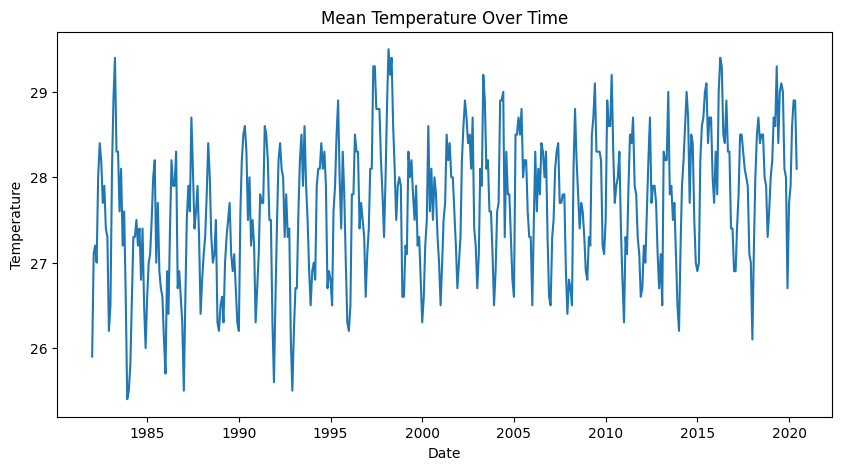

In [ ]:
# visualisation
plt.figure(figsize=(10, 5))
plt.plot(df["mean_temp"])
plt.title("Mean Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.show()

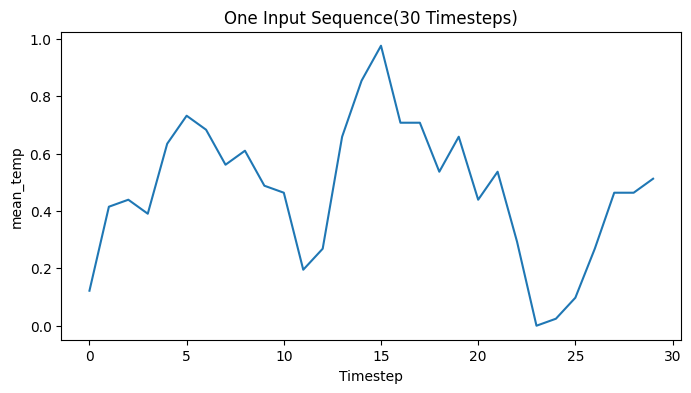

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(X[0])
plt.title("One Input Sequence(30 Timesteps)")
plt.xlabel("Timestep")
plt.ylabel("mean_temp")
plt.show()

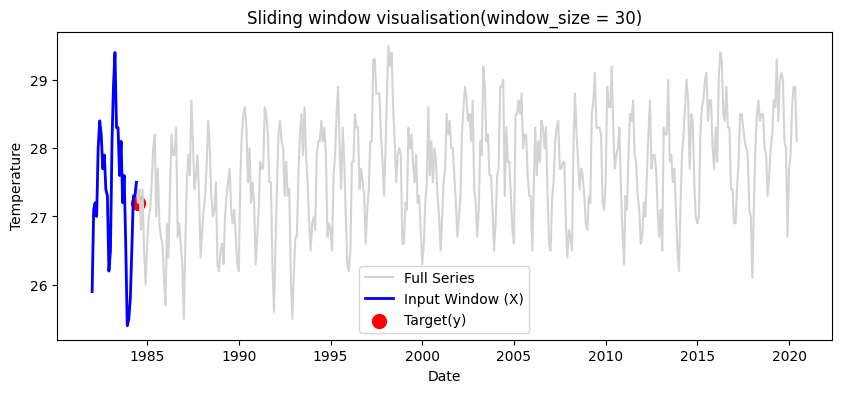

In [ ]:
# Choose a sample index
i = 30
window_size=30
plt.figure(figsize=(10, 4))


# Full Series
plt.plot(df.index, df["mean_temp"].values,color = "lightgray", label='Full Series')

# Sliding window (X)

plt.plot(df.index[i-window_size:i], df["mean_temp"].values[i-window_size:i],
         color = "blue", linewidth = 2, label = 'Input Window (X)')

# target value(y)

plt.scatter(df.index[i],df["mean_temp"].values[i], color = "red", s = 100, label = "Target(y)")

plt.title("Sliding window visualisation(window_size = 30)")

plt.xlabel("Date")
plt.ylabel("Temperature")
plt.legend()
plt.show()

In [ ]:
#  build the  VanilaRNN (SimpleRNN) model & train the model
model_rnn = Sequential([
    SimpleRNN(50, return_sequences=False, input_shape=(window_size, 1)),
    Dense(1)
])
model_rnn.compile(optimizer='adam', loss='mean_squared_error')
model_rnn.summary()
history_rnn = model_rnn.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0840 - val_loss: 0.0574
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0303 - val_loss: 0.0233
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0196 - val_loss: 0.0253
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0183 - val_loss: 0.0165
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0177 - val_loss: 0.0193
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0142 - val_loss: 0.0206
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0152 - val_loss: 0.0187
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0145 - val_loss: 0.0147
Epoch 9/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0132 - val_loss: 0.0155
Epoch 10/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0121 - val_loss: 0.0123


In [ ]:
# model prediction
prediction = model_rnn.predict(X_test)
prediction= scaler.inverse_transform(prediction)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [ ]:
actual = scaler.inverse_transform(y_test)


for i in range(len(prediction)):
  print(f"Predicted:{prediction[i][0]:.2f}, Actual:{actual[i][0]:.2f}")

Predicted:27.95, Actual:28.20
Predicted:28.84, Actual:28.20
Predicted:28.85, Actual:29.00
Predicted:28.22, Actual:27.80
Predicted:28.16, Actual:27.90
Predicted:27.88, Actual:27.50
Predicted:27.74, Actual:27.70
Predicted:27.37, Actual:27.10
Predicted:27.11, Actual:26.50
Predicted:27.11, Actual:26.20
Predicted:27.23, Actual:27.20
Predicted:27.54, Actual:27.90
Predicted:28.16, Actual:28.20
Predicted:28.71, Actual:28.60
Predicted:28.66, Actual:29.00
Predicted:28.20, Actual:28.70
Predicted:28.04, Actual:27.70
Predicted:27.96, Actual:28.50
Predicted:27.85, Actual:28.40
Predicted:27.63, Actual:27.50
Predicted:27.26, Actual:27.00
Predicted:27.25, Actual:26.90
Predicted:27.63, Actual:27.00
Predicted:27.99, Actual:28.20
Predicted:28.23, Actual:28.60
Predicted:28.85, Actual:28.70
Predicted:28.90, Actual:29.00
Predicted:28.39, Actual:29.10
Predicted:28.15, Actual:28.40
Predicted:28.24, Actual:28.70
Predicted:28.12, Actual:28.70
Predicted:27.92, Actual:28.00
Predicted:27.47, Actual:27.70
Predicted:

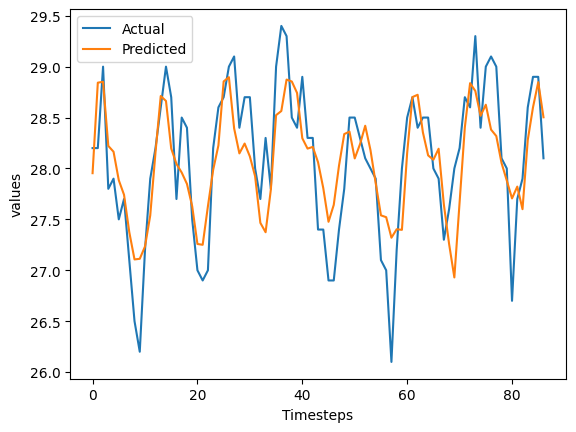

In [ ]:
# Plotting actual vs prdeicted values

plt.figure()
plt.plot(actual, label = "Actual")
plt.plot(prediction,  label = "Predicted")
plt.xlabel("Timesteps")
plt.ylabel("values")
plt.legend()
plt.show()

In [ ]:
# Evaluate the models
loss_model_deep_rnn = model_deep_rnn.evaluate(X_test, y_test, verbose=0)
loss_model_rnn = model_rnn.evaluate(X_test, y_test, verbose=0)

print(f"Model (Deep RNN) Test Loss: {loss_model_deep_rnn:.4f}")
print(f"Model_rnn (default activation) Test Loss: {loss_model_rnn:.4f}")

Model (Deep RNN) Test Loss: 0.0164
Model_rnn (default activation) Test Loss: 0.0123


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Deep / Stacked RNN model
model_deep_rnn = Sequential([
    SimpleRNN(50, return_sequences=True, input_shape=(window_size, 1)),
    SimpleRNN(50),
    Dense(1)
])

# Compile model
model_deep_rnn.compile(optimizer='adam', loss='mse')

# Model summary
model_deep_rnn.summary()

# Train model
history_deep = model_deep_rnn.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_3 (SimpleRNN)        │ (None, 30, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 0.1521 - val_loss: 0.1108
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0371 - val_loss: 0.0447
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0288 - val_loss: 0.0201
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0215 - val_loss: 0.0188
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0166 - val_loss: 0.0208
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0149 - val_loss: 0.0225
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0154 - val_loss: 0.0142
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0143 - val_loss: 0.0125
Epoch 9/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0121 - val_loss: 0.0130
Epoch 10/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0127 - val_loss: 0.0120


In [ ]:
# Bidirectional RNN
model_birnn = Sequential([Bidirectional(SimpleRNN(50), input_shape = (window_size,1)), Dense(1)])
model_birnn.compile(optimizer = 'adam', loss = 'mse')
model_birnn.summary()
history_bi = model_birnn.fit(X_train, y_train, epochs =10, batch_size =32, validation_data = (X_test, y_test))

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 100)            │         5,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,301 (20.71 KB)

 Trainable params: 5,301 (20.71 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 0.1234 - val_loss: 0.0311
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0336 - val_loss: 0.0264
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0198 - val_loss: 0.0279
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0181 - val_loss: 0.0216
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0167 - val_loss: 0.0225
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0164 - val_loss: 0.0189
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0147 - val_loss: 0.0211
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0159 - val_loss: 0.0146
Epoch 9/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0133 - val_loss: 0.0135
Epoch 10/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0133 - val_loss: 0.0135


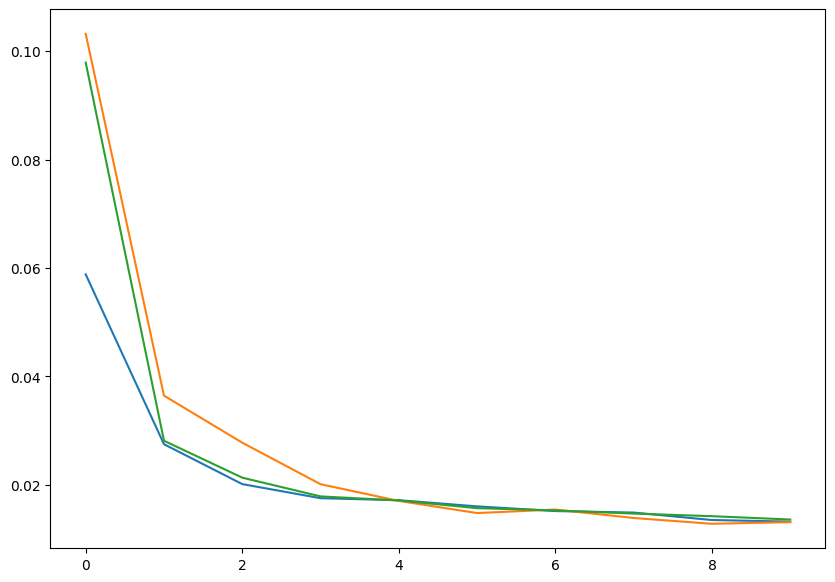

In [ ]:
# plotting loss curves

plt.figure(figsize=(10, 7))
plt.plot(history_rnn.history["loss"], label = "VanilaRNN" )
plt.plot(history_deep.history["loss"], label = "DeepRNN")
plt.plot(history_bi.history["loss"], label = "BidirectionalRNN")

In [ ]:
from typing import ValuesView
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt

# Generate predictions from the SimpleRNN model
y_pred_scaled = model_rnn.predict(X_test)

# Inverse transform the scaled predictions and actual values to the original scale
y_pred = scaler.inverse_transform(y_pred_scaled)
y_actual = scaler.inverse_transform(y_test)

# Calculate RMSE
rmse = sqrt(mean_squared_error(y_actual, y_pred))
print(f"RMSE for SimpleRNN: {rmse:.4f}")

mae = mean_absolute_error(y_actual, y_pred)
print(mae)

R_squared = r2_score(y_actual, y_pred)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
RMSE for SimpleRNN: 0.4553
0.3750929733802533


In [ ]:
# Using  various types  of LSTM model

# Utility function
def compile_and_train(model,name,  epochs=10, batch_size=32):
  model.compile(optimizer = "adam", loss =  "mse")


  history= model.fit(X_train,y_train, epochs = epochs, batch_size = batch_size, verbose = 1)
  print(f"{name} trained")
  return history

In [ ]:
# build the stacked LSTM model
window_size = 30
batch_size= 32
epochs=10

stacked_lstm = Sequential([
    Input(shape=(window_size, 1)),
    LSTM(50, return_sequences=True),
    LSTM(50),
    Dense(1)
])
stacked_lstm.summary()







Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
hist_stacked = compile_and_train(stacked_lstm, "Stacked LSTM", epochs =10, batch_size = 32)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.1780
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0422
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0427
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0356
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - loss: 0.0373
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0343
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0360
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0362
Epoch 9/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0354
Epoch 10/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0356
Stacked LSTM trained


In [ ]:
# model prediction
prediction = stacked_lstm.predict(X_test)
prediction = scaler.inverse_transform(prediction)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 231ms/step


In [ ]:
# want to all the actual values with prediction data
actual = scaler.inverse_transform(y_test)
for i in range (len(prediction)):
  print(f"Predicted:{prediction[i][0]:.2f}, Actual:{actual[i][0]:.2f}")

Predicted:27.50, Actual:28.20
Predicted:27.52, Actual:28.20
Predicted:27.55, Actual:29.00
Predicted:27.61, Actual:27.80
Predicted:27.64, Actual:27.90
Predicted:27.66, Actual:27.50
Predicted:27.67, Actual:27.70
Predicted:27.67, Actual:27.10
Predicted:27.65, Actual:26.50
Predicted:27.60, Actual:26.20
Predicted:27.54, Actual:27.20
Predicted:27.50, Actual:27.90
Predicted:27.49, Actual:28.20
Predicted:27.51, Actual:28.60
Predicted:27.55, Actual:29.00
Predicted:27.62, Actual:28.70
Predicted:27.68, Actual:27.70
Predicted:27.70, Actual:28.50
Predicted:27.74, Actual:28.40
Predicted:27.77, Actual:27.50
Predicted:27.77, Actual:27.00
Predicted:27.75, Actual:26.90
Predicted:27.71, Actual:27.00
Predicted:27.67, Actual:28.20
Predicted:27.66, Actual:28.60
Predicted:27.69, Actual:28.70
Predicted:27.73, Actual:29.00
Predicted:27.78, Actual:29.10
Predicted:27.84, Actual:28.40
Predicted:27.88, Actual:28.70
Predicted:27.92, Actual:28.70
Predicted:27.95, Actual:28.00
Predicted:27.96, Actual:27.70
Predicted:

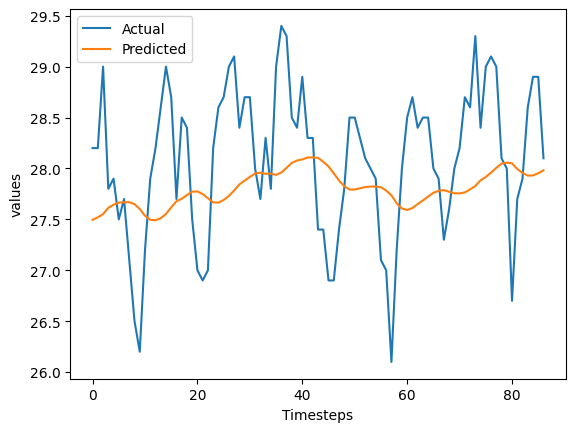

In [ ]:
# plotting actual vs predicted values
plt.figure()
plt.plot(actual, label = "Actual")
plt.plot(prediction,  label = "Predicted")
plt.xlabel("Timesteps")
plt.ylabel("values")
plt.legend()
plt.show()

In [ ]:
# Bidirectional LSTM
bilstm = Sequential([Input(shape=(window_size, 1)),
                     Bidirectional(LSTM(50, return_sequences=False)),
                     Dense(1)])
bilstm.summary()
bilstm.compile(optimizer='adam', loss='mse')

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 100)            │        20,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,901 (81.64 KB)

 Trainable params: 20,901 (81.64 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:


# Multilayer LSTM (multiple LSTM layers with decreasing units)
multilayer_lstm = Sequential([
    Input(shape=(window_size, 1)),
    LSTM(100, return_sequences=True),
    LSTM(50, return_sequences=True),
    LSTM(25),
    Dense(1)
])

# Model summary
multilayer_lstm.summary()

# Compile model
multilayer_lstm.compile(optimizer='adam', loss='mse')

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 30, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 30, 50)         │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 25)             │         7,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,626 (307.13 KB)

 Trainable params: 78,626 (307.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Residual LSTM
import tensorflow as tf

from tensorflow.keras.layers import Add
from tensorflow.keras.models import Model


inputs = Input(shape=(window_size,1))
x = LSTM(50, return_sequences=True)(inputs)
x = LSTM(50)(x)
shortcut = LSTM(50)(inputs)
output = Add()([x, shortcut])
output = Dense(1)(output)
residual_lstm = tf.keras.Model(inputs=inputs, outputs=output)
residual_lstm.summary()
hist_residual = compile_and_train(residual_lstm, "Residual LSTM")


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 30, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ (None, 30, 50)    │     10,400 │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_7 (LSTM)       │ (None, 50)        │     20,200 │ lstm_6[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_8 (LSTM)       │ (None, 50)        │     10,400 │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 50)        │          0 │ lstm_7[0][0],     │
│                     │                   │            │ lstm_8[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │         51 │ add[0][0]         │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 41,051 (160.36 KB)

 Trainable params: 41,051 (160.36 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - loss: 0.1653
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0383
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0378
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0330
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0385
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0346
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0368
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0334
Epoch 9/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0329
Epoch 10/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0326
Residual LSTM trained


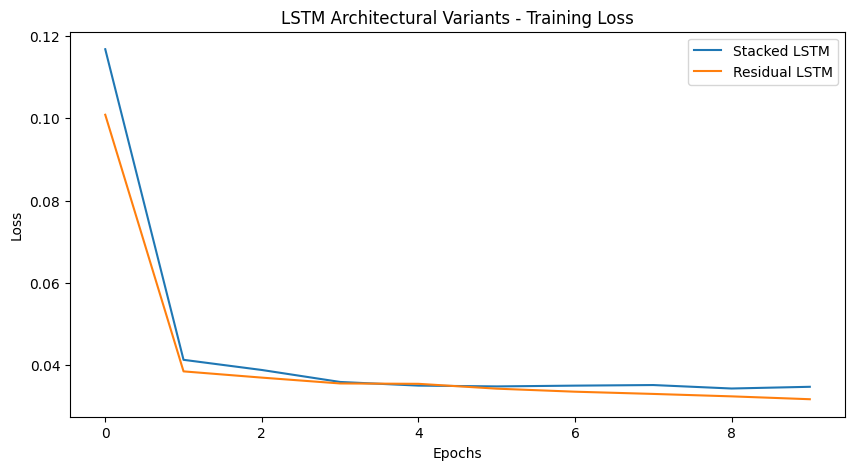

In [ ]:
import matplotlib.pyplot as plt

# Training loss comparison
plt.figure(figsize=(10,5))

plt.plot(hist_stacked.history['loss'], label='Stacked LSTM')

plt.plot(hist_residual.history['loss'], label='Residual LSTM')

plt.title("LSTM Architectural Variants - Training Loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()

In [ ]:
# Evaluation

from typing import ValuesView
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt

# Generate predictions from the Stacked LSTM model
y_pred_scaled = stacked_lstm.predict(X_test)

# Inverse transform the scaled predictions and actual values to the original scale
y_pred = scaler.inverse_transform(y_pred_scaled)
y_actual = scaler.inverse_transform(y_test)

# Calculate RMSE
rmse = sqrt(mean_squared_error(y_actual, y_pred))
print(f"RMSE for Stacked LSTM: {rmse:.4f}")

mae = mean_absolute_error(y_actual, y_pred)
print(mae)

R_squared = r2_score(y_actual, y_pred)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
RMSE for Stacked LSTM: 0.7832
0.6612078129560097
